<a href="https://colab.research.google.com/github/Alenushka2013/Stepic/blob/master/210946_Genetic_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [32]:
# Цільова функція
def objective_function(x, y):
  return 300 * x + 400 * y

# Обмеження 1
def constraint1(x, y):
  return x + y <= 40

# Обмеження 2
def constraint2(x, y):
  return x + 2 * y <= 60

In [33]:
def genetic_algorithm(population_size, num_generation):
    # 1. Ініціалізація
    population = [(random.uniform(0, 60), random.uniform(0, 40)) for _ in range(population_size)]
    best_solution = None
    best_cost = float('-inf')
    history = []

    for generation in range(num_generation):
        # 2. Оцінка
        feasible_population = [ind for ind in population if constraint1(*ind) and constraint2(*ind)]
        feasible_cost = [objective_function(*ind) for ind in feasible_population]

        if not feasible_population:
            continue

        # 3. Відбір
        parents = random.choices(feasible_population, weights=feasible_cost, k=population_size)

        # 4. Рекомбінація
        offspring = []
        for _ in range(population_size):
            parent1, parent2 = random.choices(parents, k=2)
            x_child = random.uniform(min(parent1[0], parent2[0]), max(parent1[0], parent2[0]))
            y_child = random.uniform(min(parent1[1], parent2[1]), max(parent1[1], parent2[1]))
            offspring.append((x_child, y_child))

        # 5. Мутація
        mutation_rate = 1 / (generation + 1)
        for i in range(population_size):
            if random.random() < mutation_rate:
                offspring[i] = (random.uniform(0, 60), random.uniform(0, 40))

        # 6. Елітизм
        if best_solution is not None:
            offspring[0] = best_solution

        population = offspring

        # 7. Пошук найкращого рішення
        feasible_solutions = [ind for ind in population if constraint1(*ind) and constraint2(*ind)]
        if feasible_solutions:
            best = max(feasible_solutions, key=lambda ind: objective_function(*ind))
            best_solution = best
            best_cost = objective_function(*best)
            history.append(best_cost)

            print(f'Generation #{generation + 1}, x = {best[0]:.2f}, y = {best[1]:.2f}, S = {best_cost:.2f}')

    # Візуалізація
    plt.figure(figsize=(9, 9))
    plt.plot(history, marker='o', linestyle='-', color='green')
    plt.grid(True)
    plt.xlabel('Generation')
    plt.ylabel('Objective')
    plt.show()

    return best_solution, best_cost

In [29]:
# def genetic_algorithm(population_size, num_generation):
#   # 1. ініціалізація
#   population = []
#   history = []

#   for i in range(population_size):
#     x = random.uniform(0, 60)
#     y = random.uniform(0, 40)
#     population.append((x, y))

#   best_solution = None
#   best_cost = float('-inf')

#   for generation in range(num_generation):
#     # 2. оцінка
#     cost = []
#     for individual in population:
#       x = individual[0]
#       y = individual[1]
#       cost.append(objective_function(x, y))
#     feasible_population = []
#     for individual in population:
#       x = individual[0]
#       y = individual[1]

#       if constraint1(x, y) and constraint2(x, y):
#         feasible_population.append(individual)

#     # 3. відбір
#     parents = []
#     feasible_cost = []

#     for individual in feasible_population:
#       x = individual[0]
#       y = individual[1]
#       feasible_cost.append(objective_function(x, y))

#     parents = random.choices(feasible_population, weights = feasible_cost, k = population_size)

#     # 4. Рекомбінація (crossover)
#     offspring = []
#     for i in range(population_size):
#       parent1, parent2 = random.choices(parents, k = 2)
#       x1 = parent1[0]
#       y1 = parent1[1]
#       x2 = parent2[0]
#       y2 = parent2[1]
#       x_child = random.uniform(min(x1, x2), max(x1, x2))
#       y_child = random.uniform(min(y1, y2), max(y1, y2))
#       offspring.append((x_child, y_child))

#     # parent1: (x1, y1) = (20; 30)
#     # parent2: (x2, y2) = (25; 15)

#     # x_child = random.uniform(min(x1, x2), max(x1, x2))
#     # x_child = random.uniform(20, 25) = 23

#     # y_child = random.uniform(min(y1, y2), max(y1, y2))
#     # y_child = random.uniform(15, 30) = 19

#     # Нащадок: (x_child, y_child) = (23; 19)

#     # 5. Мутація
#     mutation_rate = 1 / (generation + 1)

#     for i in range(population_size):
#       if random.random() < mutation_rate:
#         # Вносимо випадкові зміни в ДНК
#         offspring[i] = (random.uniform(0, 60), random.uniform(0, 40))

#     # mutation_rate = 0.25 (generation  = 3)
#     # random.random() = 0.38
#     # 0.38 < 0.25 -> False -> offspring[i] без змін

#     # mutation_rate = 0.25 (generation  = 3)
#     # random.random() = 0.17
#     # 0.17 < 0.38 -> False -> offspring[i] заміняєтьсяя випадковим нащадком

#     # 6. Елітизм (збереження кращих ріщень в популяції)

#     if best_solution is not None:
#       offspring[0] = best_solution

#     population = offspring

#     # 7. Пошук оптимального розв'язку
#     feasible_solutions = []
#     x = individual[0]
#     y = individual[1]

#     if constraint1(x, y) and constraint2(x, y):
#       feasible_solutions.append((x, y))

#     if feasible_solutions:
#       best = max(feasible_solutions, key = lambda x: objective_function(x[0], x[1]))
#       best_solution = best
#       best_cost = objective_function(best_solution[0], best_solution[1])
#       history.append(best_cost)

#       print(f'Generation #{generation + 1}, x = {best_solution[0]}, y = {best_solution[1]}, S = {best_cost}')


#   # Visualization

#   plt.figure(figsize = (9, 9))
#   plt.plot(history, marker = 'o', linestyle = '-', color = 'green')
#   plt.grid(True)
#   plt.xlabel('Generation')
#   plt.ylabel('Target')
#   plt.show()

#   return best_solution, best_cost

Generation #1, x = 20.91, y = 16.53, S = 12884.24
Generation #2, x = 19.93, y = 18.61, S = 13420.78
Generation #3, x = 17.66, y = 21.08, S = 13731.06
Generation #4, x = 17.66, y = 21.08, S = 13731.06
Generation #5, x = 19.67, y = 19.93, S = 13875.57
Generation #6, x = 19.67, y = 19.93, S = 13875.57
Generation #7, x = 19.67, y = 19.93, S = 13875.57
Generation #8, x = 19.67, y = 19.93, S = 13875.57
Generation #9, x = 19.67, y = 19.93, S = 13875.57
Generation #10, x = 19.67, y = 19.93, S = 13875.57
Generation #11, x = 19.67, y = 19.93, S = 13875.57
Generation #12, x = 19.67, y = 19.93, S = 13875.57
Generation #13, x = 19.67, y = 19.93, S = 13875.57
Generation #14, x = 19.67, y = 19.93, S = 13875.57
Generation #15, x = 19.67, y = 19.93, S = 13875.57
Generation #16, x = 19.67, y = 19.93, S = 13875.57
Generation #17, x = 19.67, y = 19.93, S = 13875.57
Generation #18, x = 19.67, y = 19.93, S = 13875.57
Generation #19, x = 19.67, y = 19.93, S = 13875.57
Generation #20, x = 19.67, y = 19.93, S 

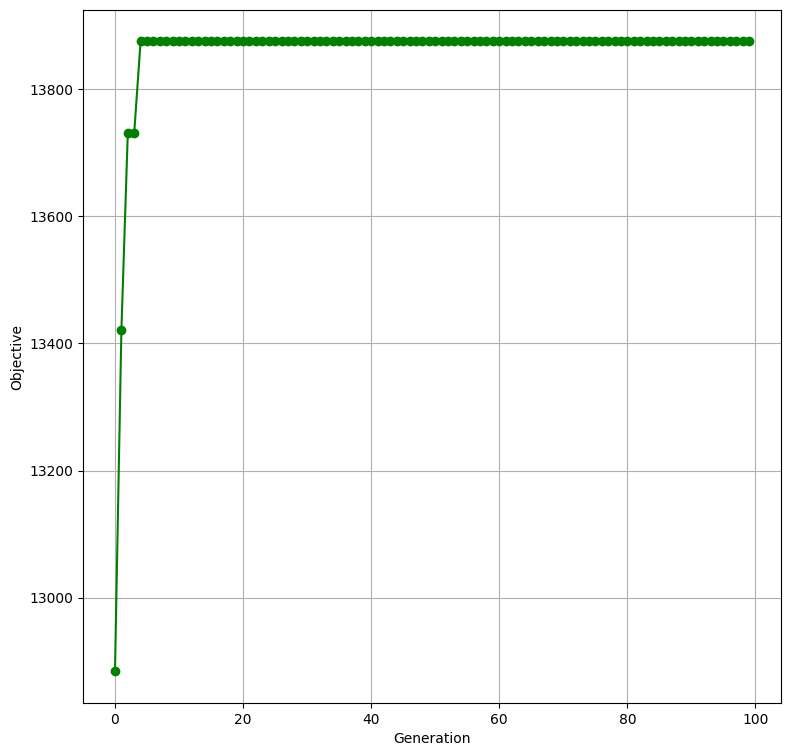

In [37]:
population_size = 100
num_generation = 100

best_solution, best_cost = genetic_algorithm(population_size, num_generation)

In [39]:
!pip install geneticalgorithm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for func-timeout: filename=func_timeout-4.3.5-py3-none-any.whl size=15077 sha256=8f77e1407462c9543a544053e5cdf9f26c179bde4f0b0b23ddcd8554e9ea9664
  Stored in directory: /root/.cache/pip/wheels/ed/94/4a/9ccd71f7284a92e4137b7dd0ce8540c40ea7c2689251504a49
Successfully built func-timeout


**S = 1.6x + 2.2 y + 1.2 z**

**0.5x + 0.7 y + 0.4 Z <= 1**

In [40]:
import numpy as np
from geneticalgorithm import geneticalgorithm as ga

In [54]:
def objective_function1(X):
    x, y, z = X

    penalty = 0

    # Перевірка обмеження
    if (0.5 * x + 0.7 * y + 0.4 * z) > 1:
        penalty = 1e6  # великий штраф замість np.inf

    return -(1.6 * x + 2.2 * y + 1.2 * z) + penalty

 The best solution found:
 [1. 0. 1.]

 Objective function:
 -2.8


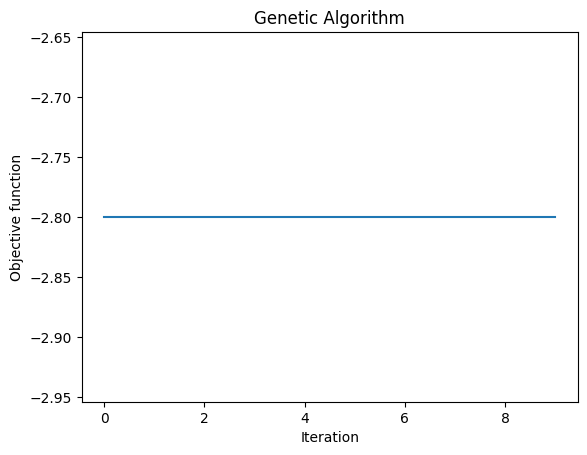

In [55]:
params = {'max_num_iteration': None,      # максимальна кількість поколінь
          'population_size': 100,         # Розмір популяції
          'mutation_probability': 0.5,    # ймовірність мутацій
          'elit_ratio': 0.01,             # частина кращих, які лишаються
          'crossover_probability': 0.5,   # ймовірність змішування ДНК батьків
          'parents_portion': 0.3,         # частина популяції, яка обрана батьками для продовження роду
          'crossover_type': 'uniform',    # гени обрані з однаковою ймовірністю для кожного з батьків
          'max_iteration_without_improv': None # максимальна кількість ітерацій без вибору нового кращого рішення
          }
model = ga(function = objective_function1, dimension = 3, variable_type = 'bool', algorithm_parameters=params)
model.run()